여러 CSV 데이터 파일 시간순으로 병합하기

1. 라이브러리 불러오기

먼저, 데이터 처리에 필요한 pandas와 파일 경로를 다루기 위한 os, glob 라이브러리를 불러옵니다.

In [1]:
import pandas as pd
import os
import glob
import re

2. 데이터 폴더 경로 설정

사용자께서 알려주신 경로와 폴더 이름을 변수로 지정합니다.

In [2]:
# 데이터 파일이 있는 폴더 경로를 지정하세요.
# 예: data/
DATA_FOLDER_PATH = 'data/'

# 찾을 파일 이름의 패턴을 지정합니다 (모든 _data.csv 파일).
FILE_PATTERN = os.path.join(DATA_FOLDER_PATH, '*_data.csv')

In [6]:
# 데이터가 있는 최상위 경로
BASE_PATH = r'C:\Users\KAMIC\Desktop'

# 데이터를 병합할 폴더 이름 목록
FOLDER_NAMES = [
    '20250813_Thinwall_316L#1'
]
#   '20250325_Ti64_thinwall'

In [11]:
# 데이터가 있는 최상위 경로
BASE_PATH = r'C:\Users\KAMIC\Desktop'

# 데이터를 병합할 폴더 이름 목록
FOLDER_NAMES = [
    '20250814_Thinwall_316L#2'
]
#   '20250325_Ti64_thinwall'

In [16]:
# 데이터가 있는 최상위 경로
BASE_PATH = r'C:\Users\KAMIC\Desktop'

# 데이터를 병합할 폴더 이름 목록
FOLDER_NAMES = [
    '20250822_Cyl_test#01'
]
#   '20250325_Ti64_thinwall'

3. 모든 폴더에서 CSV 파일 목록 불러오기

지정한 두 폴더를 모두 탐색하여, 그 안에 있는 모든 .csv 파일의 전체 경로를 하나의 리스트에 담습니다.

In [17]:
all_file_paths = []
for folder in FOLDER_NAMES:
    # 각 폴더의 전체 경로 생성
    folder_path = os.path.join(BASE_PATH, folder)
    # 해당 폴더 내의 모든 .csv 파일을 찾음
    csv_files_in_folder = glob.glob(os.path.join(folder_path, '*.csv'))
    # 찾은 파일들을 전체 리스트에 추가
    all_file_paths.extend(csv_files_in_folder)

print(f"총 {len(all_file_paths)}개의 CSV 파일을 찾았습니다.")

총 70개의 CSV 파일을 찾았습니다.


4. 파일 이름 기준으로 정확하게 정렬하기

파일 경로에서 파일 이름(1_data.csv 등) 앞의 숫자를 추출하여, 1, 2, ..., 10, 11, ... 순서가 되도록 정확하게 정렬합니다.

In [18]:
# 파일 이름에서 숫자를 추출하여 정렬 기준으로 삼는 함수
def sort_key(path):
    filename = os.path.basename(path)
    match = re.match(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return -1 # 숫자로 시작하지 않는 파일은 맨 뒤로

# 정렬 함수를 사용하여 전체 파일 경로 리스트를 정렬합니다.
sorted_file_paths = sorted(all_file_paths, key=sort_key)

print("정렬된 파일 목록 (상위 10개):")
for path in sorted_file_paths[:10]:
    print(path)

정렬된 파일 목록 (상위 10개):
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\1_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\2_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\3_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\4_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\10_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\11_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\12_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\13_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\14_data.csv
C:\Users\KAMIC\Desktop\20250822_Cyl_test#01\15_data.csv


5. 모든 CSV 파일 불러와서 하나로 병합하기

정렬된 순서대로 각 CSV 파일을 데이터프레임으로 읽어온 뒤, pd.concat을 이용해 하나의 거대한 데이터프레임으로 합칩니다.

In [19]:
dataframe_list = []

for path in sorted_file_paths:
    try:
        df = pd.read_csv(path)
        dataframe_list.append(df)
        print(f"'{os.path.basename(path)}' 파일 로드 성공 (행: {len(df)}개)")
    except Exception as e:
        print(f"'{os.path.basename(path)}' 파일 로드 실패: {e}")

# 리스트에 담긴 모든 데이터프레임을 하나로 합칩니다.
# ignore_index=True는 각 파일의 기존 인덱스를 무시하고 새로 인덱스를 부여하는 옵션입니다.
merged_df = pd.concat(dataframe_list, ignore_index=True)

print("\n모든 파일 병합 완료!")

'1_data.csv' 파일 로드 성공 (행: 21240개)
'2_data.csv' 파일 로드 성공 (행: 8055개)
'3_data.csv' 파일 로드 성공 (행: 6831개)
'4_data.csv' 파일 로드 성공 (행: 6857개)
'10_data.csv' 파일 로드 성공 (행: 5871개)
'11_data.csv' 파일 로드 성공 (행: 6331개)
'12_data.csv' 파일 로드 성공 (행: 5300개)
'13_data.csv' 파일 로드 성공 (행: 6502개)
'14_data.csv' 파일 로드 성공 (행: 18300개)
'15_data.csv' 파일 로드 성공 (행: 21806개)
'16_data.csv' 파일 로드 성공 (행: 2866개)
'17_data.csv' 파일 로드 성공 (행: 3949개)
'18_data.csv' 파일 로드 성공 (행: 2833개)
'19_data.csv' 파일 로드 성공 (행: 3054개)
'20_data.csv' 파일 로드 성공 (행: 3389개)
'21_data.csv' 파일 로드 성공 (행: 3734개)
'22_data.csv' 파일 로드 성공 (행: 3964개)
'23_data.csv' 파일 로드 성공 (행: 4234개)
'24_data.csv' 파일 로드 성공 (행: 4326개)
'25_data.csv' 파일 로드 성공 (행: 4556개)
'26_data.csv' 파일 로드 성공 (행: 4476개)
'27_data.csv' 파일 로드 성공 (행: 4796개)
'28_data.csv' 파일 로드 성공 (행: 4895개)
'29_data.csv' 파일 로드 성공 (행: 5012개)
'30_data.csv' 파일 로드 성공 (행: 5036개)
'31_data.csv' 파일 로드 성공 (행: 11620개)
'32_data.csv' 파일 로드 성공 (행: 1316개)
'33_data.csv' 파일 로드 성공 (행: 5018개)
'34_data.csv' 파일 로드 성공 (행: 5392개)
'35_data.csv' 

6. 병합 결과 확인 및 저장

최종적으로 병합된 데이터의 정보를 확인하고, 바탕화면 경로에 merged_data_total.csv 파일로 저장합니다.

In [20]:
print("--- 최종 병합 결과 ---")
print(f"전체 행 수: {merged_df.shape[0]}개")
print(f"전체 열 수: {merged_df.shape[1]}개")

print("\n[병합된 데이터 미리보기 (상위 5개 행)]")
display(merged_df.head())

# 저장할 파일의 전체 경로를 지정합니다.
output_path = os.path.join(BASE_PATH, 'merged_data_20250813_20250822_Cyl_test#01.csv')

# 데이터프레임을 CSV 파일로 저장합니다.
merged_df.to_csv(output_path, index=False)

print(f"\n병합된 데이터가 '{output_path}' 경로에 성공적으로 저장되었습니다.")

--- 최종 병합 결과 ---
전체 행 수: 448458개
전체 열 수: 19개

[병합된 데이터 미리보기 (상위 5개 행)]


,time,X,Y,Z,E1,E2,S_LP,S_RS,S_WS,R_LP,R_RS,R_WS,MPT,MPA,MPW,LOAD,CONTACT,BEAD_NUMBER,LASER_ON
0,08_22_10_27_37_879,56.72,-1.01,43.94,0.0,45.0,3200,0.00833,2.0312,0,0.00667,0.0,706.51717,0.0,0.0,2.95773,0.37455,6,False
1,08_22_10_27_37_897,56.72,-1.01,43.94,0.0,45.0,3200,0.00833,2.0312,0,0.00667,0.0,706.51717,0.0,0.0,2.95902,0.43261,6,False
2,08_22_10_27_37_905,56.72,-1.01,43.94,0.0,45.0,3200,0.00833,2.0312,0,0.00667,0.0,706.51717,0.0,0.0,2.96031,0.41713,6,False
3,08_22_10_27_38_083,56.72,-1.02,42.45,0.0,45.0,3200,0.00833,2.0312,0,0.00833,0.0,706.51717,0.0,0.0,2.96160,0.41326,6,False
4,08_22_10_27_38_091,56.72,-1.02,42.45,0.0,45.0,3200,0.00833,2.0312,0,0.00833,0.0,706.51717,0.0,0.0,2.96418,0.43648,6,False



병합된 데이터가 'C:\Users\KAMIC\Desktop\merged_data_20250813_20250822_Cyl_test#01.csv' 경로에 성공적으로 저장되었습니다.


네, 병합된 파일의 특정 열 값이 시간 순서대로 올바르게 증가하는지(Linearly Increasing) 확인하는 것은 데이터 정합성을 검증하는 매우 중요한 과정입니다.

두 가지 방법을 제안해 드립니다.

시각화 (그래프): 데이터의 전체적인 추세를 한눈에 파악할 수 있습니다.

코드 (Pandas 함수): True/False로 명확하게 증가 여부를 판별할 수 있습니다.

아래 Jupyter Notebook 코드를 통해 두 가지 방법을 모두 사용해 보겠습니다. 가장 의미 있는 time 열을 기준으로 확인하겠습니다.

병합된 데이터의 열(Column) 증가 확인

1. 라이브러리 및 데이터 불러오기

먼저, 필요한 라이브러리와 병합된 merged_data.csv 파일을 불러옵니다.

In [21]:
import os
import pandas as pd

# 실행 경로를 바탕화면으로 이동
os.chdir(r"C:\Users\KAMIC\Desktop")
print("현재 작업 디렉토리:", os.getcwd())

# 파일 불러오기 (상대경로)
df = pd.read_csv("merged_data_total.csv")

# 시간 컬럼 변환
df['time_datetime'] = pd.to_datetime(
    df['time'],
    format='%m_%d_%H_%M_%S_%f',
    errors='coerce'
)

print(df.info())


현재 작업 디렉토리: C:\Users\KAMIC\Desktop
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39500 entries, 0 to 39499
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           39500 non-null  object        
 1   X              39500 non-null  float64       
 2   Y              39500 non-null  float64       
 3   Z              39500 non-null  float64       
 4   E1             39500 non-null  float64       
 5   E2             39500 non-null  float64       
 6   S_LP           39500 non-null  int64         
 7   S_RS           39500 non-null  float64       
 8   S_WS           39500 non-null  float64       
 9   R_LP           39500 non-null  int64         
 10  R_RS           39500 non-null  float64       
 11  R_WS           39500 non-null  float64       
 12  MPT            39500 non-null  float64       
 13  MPA            39500 non-null  float64       
 14  MPW            39500 non-null  floa

In [22]:
# 데이터 프레임 상위 5개 확인
print(df.head())

# 결측치 확인
print(df.isnull().sum())

# 기본 통계량
print(df.describe(include='all'))


                 time      X     Y     Z    E1      E2  S_LP     S_RS    S_WS  \
0  03_26_13_34_00_973  50.32  50.0  6.49 -0.32  342.88  3000  0.04167  0.2344   
1  03_26_13_34_01_033  50.32  50.0  6.49 -0.32  342.88  3000  0.04167  0.2344   
2  03_26_13_34_01_058  50.32  50.0  6.49 -0.32  342.88  3000  0.04167  0.2344   
3  03_26_13_34_01_069  50.32  50.0  6.38 -0.32  342.88  3000  0.04167  0.2344   
4  03_26_13_34_01_077  50.32  50.0  6.38 -0.32  342.88  3000  0.04167  0.2344   

   R_LP     R_RS  R_WS        MPT  MPA  MPW     LOAD  CONTACT  BEAD_NUMBER  \
0     0  0.00083   0.0  706.00105  0.0  0.0  2.66999  0.44423            2   
1     0  0.00083   0.0  706.25911  0.0  0.0  2.66096  0.35778            2   
2     0  0.00083   0.0  706.25911  0.0  0.0  2.66354  0.47261            2   
3     0  0.00667   0.0  706.77523  0.0  0.0  2.66612  0.35003            2   
4     0  0.00667   0.0  706.77523  0.0  0.0  2.66612  0.35003            2   

   LASER_ON           time_datetime  
0     

LASER_ON
False    22074
True     17426
Name: count, dtype: int64


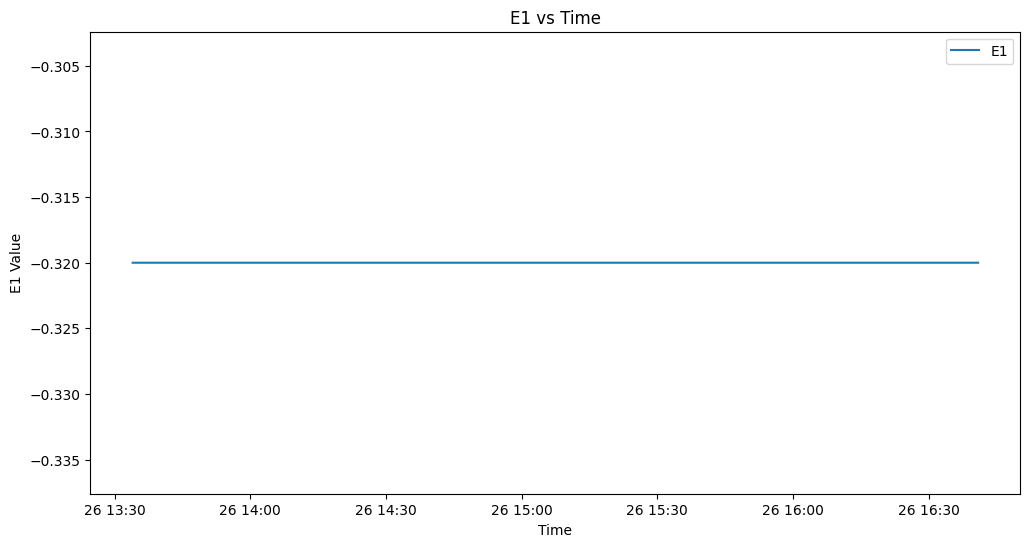

In [23]:
import matplotlib.pyplot as plt

# 시간 순 정렬
df = df.sort_values(by='time_datetime')

# 레이저 켜짐(LASER_ON) 여부에 따라 갯수 확인
print(df['LASER_ON'].value_counts())

# 시간별 어떤 값(E1 예시)을 선 그래프로 보기
plt.figure(figsize=(12, 6))
plt.plot(df['time_datetime'], df['E1'], label="E1")
plt.xlabel("Time")
plt.ylabel("E1 Value")
plt.title("E1 vs Time")
plt.legend()
plt.show()


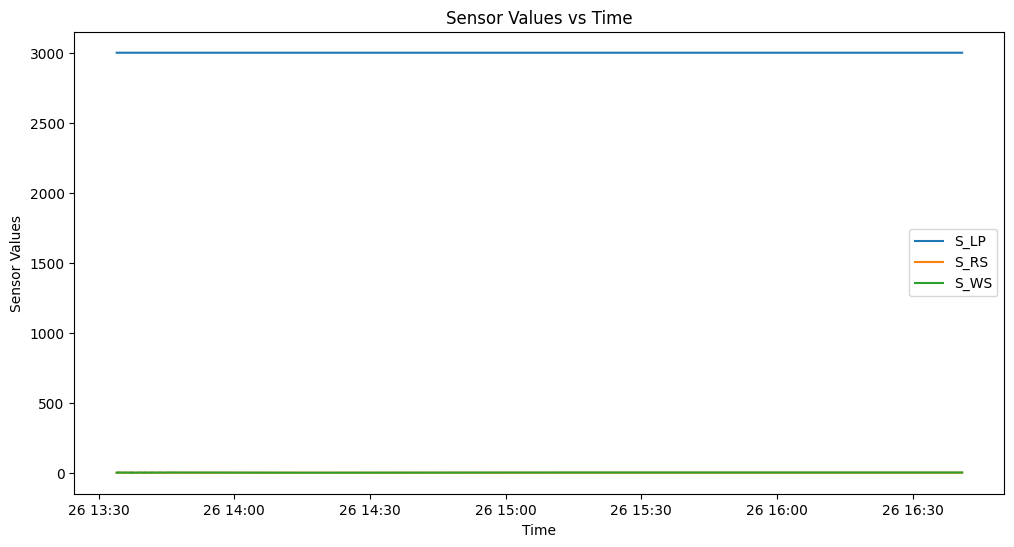

In [24]:
# 예: 여러 센서를 같은 플롯에 비교
plt.figure(figsize=(12, 6))
plt.plot(df['time_datetime'], df['S_LP'], label="S_LP")
plt.plot(df['time_datetime'], df['S_RS'], label="S_RS")
plt.plot(df['time_datetime'], df['S_WS'], label="S_WS")
plt.xlabel("Time")
plt.ylabel("Sensor Values")
plt.title("Sensor Values vs Time")
plt.legend()
plt.show()


방법 1: 시각적으로 확인하기 (그래프)

time 열을 y축으로, 데이터의 순서(인덱스)를 x축으로 하여 꺾은선 그래프를 그려봅니다.

그래프가 꾸준히 우상향한다면, 데이터가 시간 순서대로 잘 정렬되어 있다는 의미입니다. 만약 중간에 뚝 떨어지는 부분이 있다면, 병합 순서에 문제가 있다는 신호입니다.

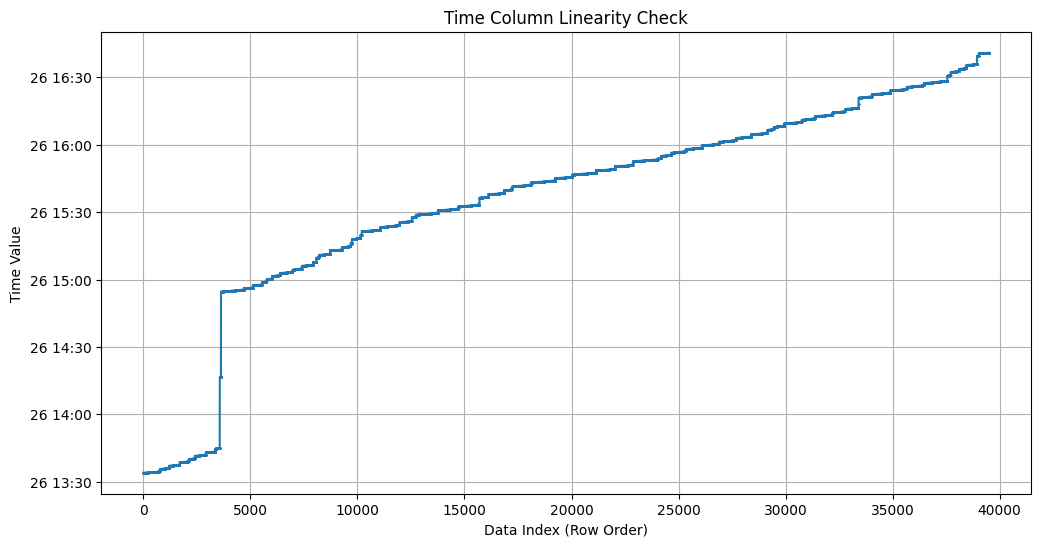

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['time_datetime'], marker='.', linestyle='-', markersize=1)
plt.title('Time Column Linearity Check')
plt.xlabel('Data Index (Row Order)')
plt.ylabel('Time Value')
plt.grid(True)
plt.show()

방법 2: 코드로 검증하기 (Pandas 함수)

pandas는 특정 열이 **단조 증가(monotonically increasing)**하는지 검사하는 매우 편리한 함수(is_monotonic_increasing)를 제공합니다. "단조 증가"란 값이 같거나 커지는 것을 의미하며, 시간 순서 검증에 완벽하게 부합합니다.

In [27]:
# 검사할 열 선택
column_to_check = 'time_datetime'

# 해당 열이 단조 증가하는지 확인합니다.
is_increasing = df[column_to_check].is_monotonic_increasing

print(f"'{column_to_check}' 열은 단조 증가(monotonically increasing)합니까?: {is_increasing}")

if is_increasing:
    print("결과: 좋습니다! 데이터가 시간 순서대로 올바르게 정렬되었습니다. 👍")
else:
    print("결과: 경고! 데이터의 시간 순서가 맞지 않는 부분이 있습니다. 병합 과정을 다시 확인해야 합니다. ⚠️")

'time_datetime' 열은 단조 증가(monotonically increasing)합니까?: True
결과: 좋습니다! 데이터가 시간 순서대로 올바르게 정렬되었습니다. 👍
